In [ ]:
# Atmosphere Basic Variables
#u,v, mslp, precip, evap, msl daily

In [18]:
#Define my working directory (important for modules)
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

#Libraries
%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import cmcrameri.cm as cmc
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import numpy as np

import mw_protocol.plotting as plotting
import mw_protocol.glac1d_toolbox as tb

import mymodules.myfunc as mf 

import cftime
import regionmask
import geopandas as gpd

#from cmcrameri import show_cmaps
#show_cmaps()

In [13]:
ds_p = {}
ds_evap = {}
ds_tsurf = {}
ds_u850 = {}
ds_v850 = {}

with mf.Timer('P-ET load'):
    for exp in ('xpraj','xprak','xpral'):
        ds_p[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.precip.monthly.nc')
        ds_evap[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.evap2.monthly.nc')
        ds_tsurf[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.tempsurf.monthly.nc')
        ds_u850[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.u850.monthly.nc')
        ds_v850[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.v850.monthly.nc')

# evap: monthly mean, kg/m^2
# precip: TOTAL PRECIPITATION RATE KG/M2/S

#1 kg/m2 is always 1 mm of rain


[P-ET load]
Elapsed: 0.4528310298919678


In [81]:
### Additional Diagnostics

ds_sicec = {}
ds_siced = {}
ds_snowcover = {}
ds_soiltemp = {}

#sea ice
with mf.Timer('Additional Diagnostics'):
    for exp in ('xpraj','xprak','xpral'):
        ds_sicec[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.iceconc.monthly.nc')
        ds_siced[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.icedepth.monthly.nc')
        ds_snowcover[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.snowdepth.monthly.nc')
        ds_soiltemp[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.soiltemp.monthly.nc')
        
        #ds_bstream = xr.open_dataset('/nfs/annie/earpal/database/experiments/tfgbj/time_series/tfgbj.streamFnpf01.monthly.nc')

[Additional Diagnostics]
Elapsed: 53.47022008895874


In [3]:
#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm

[Land sea mask loader]
Elapsed: 0.20179963111877441


In [48]:
ds_p['xpraj'].mean(dim='t').isel(surface=0).precip_mm_srf*60*60*24*30

<xarray.DataArray 'precip_mm_srf' (latitude: 73, longitude: 96)>
array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [5.0149   , 5.1067767, 5.0184517, ..., 5.573565 , 5.1806574,
        5.168369 ],
       [5.868511 , 5.745594 , 5.892262 , ..., 6.214334 , 6.0350804,
        5.814551 ],
       ...,
       [1.3259189, 1.2419821, 1.2350652, ..., 1.960176 , 1.7277935,
        1.4837273],
       [1.1314684, 1.1243042, 1.1095433, ..., 1.0255181, 1.002791 ,
        1.0838233],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * longitude  (longitude) float32 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
    surface    float32 0.0

# Annual Mean Maps and Zonal Averages

### Surface Temperature

In [9]:
lon_atm, lat_atm = ds_p['xpraj'].longitude.values, ds_p['xpraj'].latitude.values
lon_atm_b, lat_atm_b = tb.create_coordinate_edges(lon_atm), lat_atm


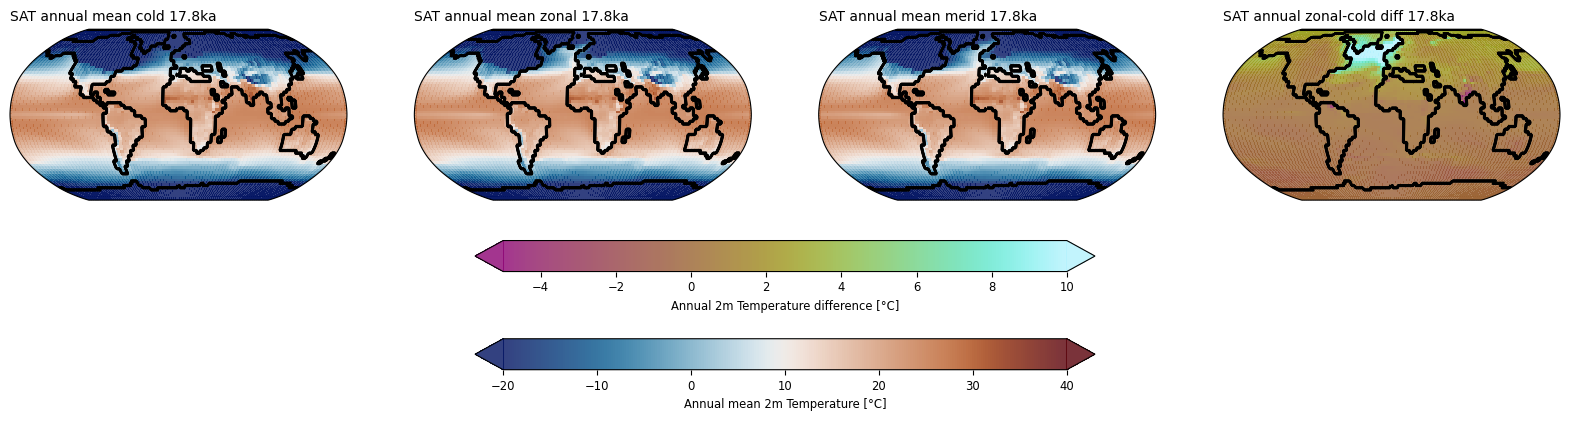

In [41]:


#projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
projection_map = ccrs.Robinson()
figMap,(axMap) = plt.subplots(nrows=1, ncols=4, subplot_kw={'projection':projection_map}, figsize=(20,5))
normpe = Normalize(vmin=-50,vmax=50,clip=False)
normsat = Normalize(vmin=-20,vmax=40,clip=False)
normsat_diff = Normalize(vmin=-5,vmax=10,clip=False)

normevap = Normalize(vmin=-50,vmax=50,clip=False)

#Winter P 'cold'
    #Precip diff percentage


#SAT cold
cmap=axMap[0].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_tsurf['xpraj']['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik,norm=normsat,alpha=0.8) 
axMap[0].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[0].set_title(f'SAT annual mean cold 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()

#SAT zonal
exp='xprak'
cmap=axMap[1].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_tsurf[exp]['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik,norm=normsat,alpha=0.8) 
axMap[1].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[1].set_title(f'SAT annual mean zonal 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()
            

#SAT zonal
exp='xpral'
cmap=axMap[2].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_tsurf[exp]['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik,norm=normsat,alpha=0.8) 
axMap[2].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[2].set_title(f'SAT annual mean merid 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()


#SAT diff

cmap_diff=axMap[3].pcolormesh(lon_atm_b, lat_atm_b,
                                   (ds_tsurf['xprak']['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15)-
                           (ds_tsurf['xpraj']['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15),
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.hawaii_r,norm=normsat_diff,alpha=0.8) 
axMap[3].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[3].set_title(f'SAT annual zonal-cold diff 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()






cb = plt.colorbar(cmap,ax=axMap,orientation='horizontal',shrink=0.4,extend='both')
cb.set_label(f"Annual mean 2m Temperature [°C]", size='small')
cb.ax.tick_params(labelsize='small')

cb2 = plt.colorbar(cmap_diff,ax=axMap,orientation='horizontal',shrink=0.4,extend='both')
cb2.set_label(f"Annual 2m Temperature difference [°C]", size='small')
cb2.ax.tick_params(labelsize='small')  


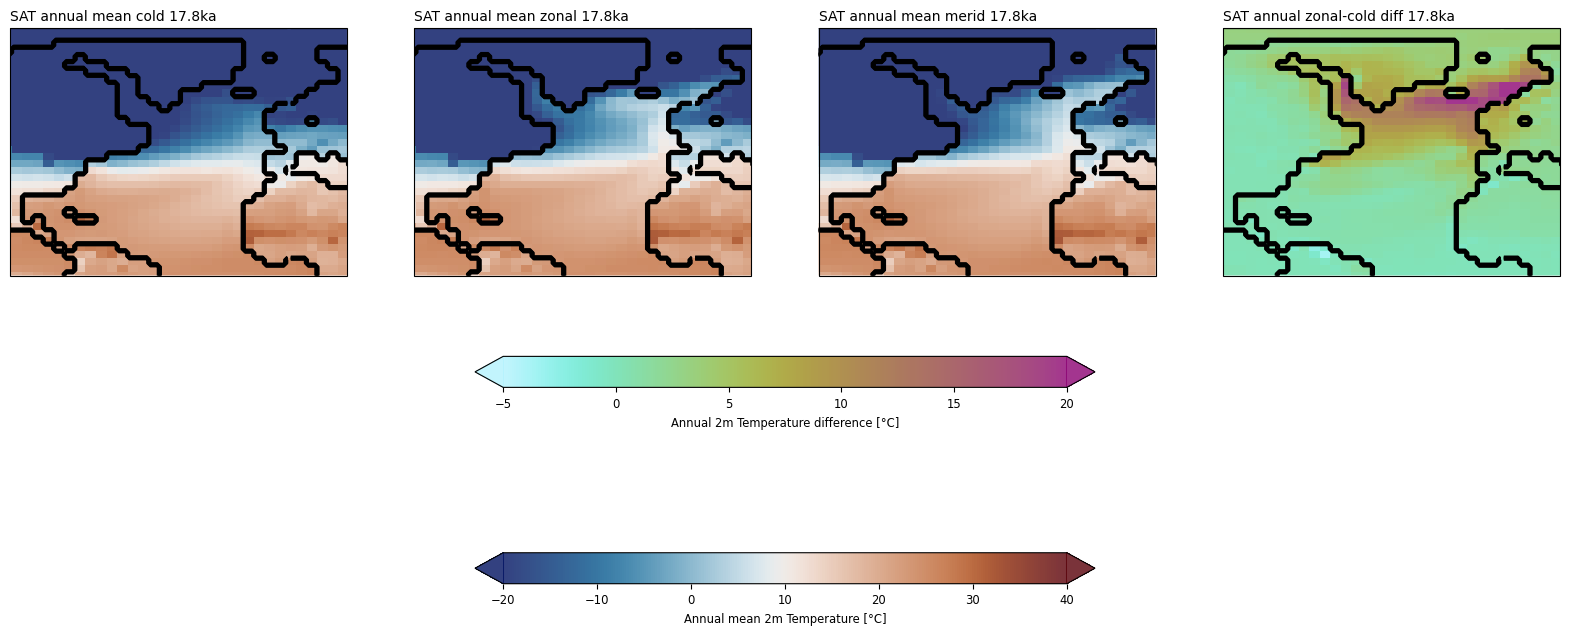

In [97]:


#projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
projection_map = ccrs.PlateCarree()
figMap,(axMap) = plt.subplots(nrows=1, ncols=4, subplot_kw={'projection':projection_map}, figsize=(20,10))
normpe = Normalize(vmin=-50,vmax=50,clip=False)
normsat = Normalize(vmin=-20,vmax=40,clip=False)
normsat_diff = Normalize(vmin=-5,vmax=20,clip=False)

normevap = Normalize(vmin=-50,vmax=50,clip=False)

#Winter P 'cold'
    #Precip diff percentage

for i in range(4):
    axMap[i].set_global()
    axMap[i].set_extent([-100,20, 0, 88], ccrs.PlateCarree())  # <-- changed here#


#SAT cold
cmap=axMap[0].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_tsurf['xpraj']['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik,norm=normsat,alpha=0.8) 
axMap[0].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[0].set_title(f'SAT annual mean cold 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()

#SAT zonal
exp='xprak'
cmap=axMap[1].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_tsurf[exp]['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik,norm=normsat,alpha=0.8) 
axMap[1].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[1].set_title(f'SAT annual mean zonal 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()
            

#SAT zonal
exp='xpral'
cmap=axMap[2].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_tsurf[exp]['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik,norm=normsat,alpha=0.8) 
axMap[2].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[2].set_title(f'SAT annual mean merid 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()


#SAT diff

cmap_diff=axMap[3].pcolormesh(lon_atm_b, lat_atm_b,
                                   (ds_tsurf['xprak']['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15)-
                           (ds_tsurf['xpraj']['temp_mm_srf.values'].mean(dim='t').isel(surface=0)-273.15),
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.hawaii_r,norm=normsat_diff,alpha=0.8) 
axMap[3].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[3].set_title(f'SAT annual zonal-cold diff 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()






cb = plt.colorbar(cmap,ax=axMap,orientation='horizontal',shrink=0.4,extend='both')
cb.set_label(f"Annual mean 2m Temperature [°C]", size='small')
cb.ax.tick_params(labelsize='small')

cb2 = plt.colorbar(cmap_diff,ax=axMap,orientation='horizontal',shrink=0.4,extend='both')
cb2.set_label(f"Annual 2m Temperature difference [°C]", size='small')
cb2.ax.tick_params(labelsize='small')  


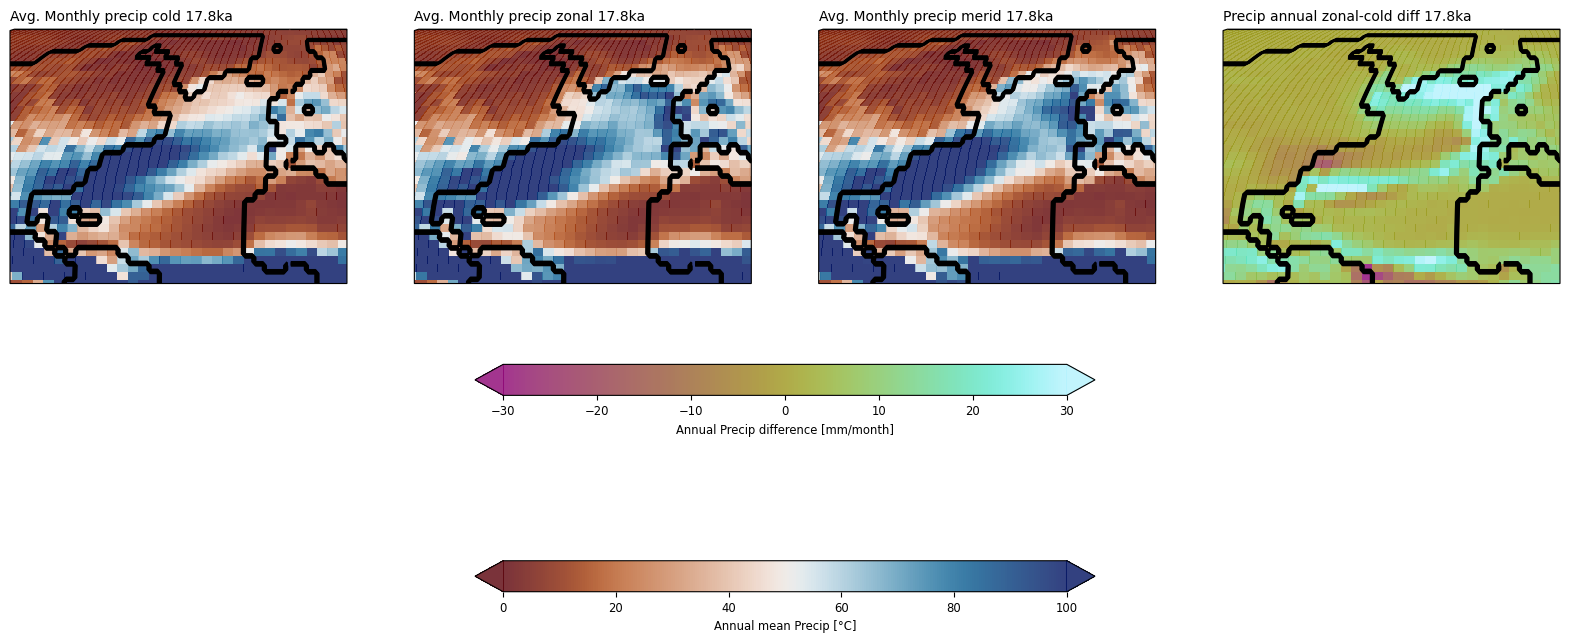

In [102]:


#projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
projection_map = ccrs.Robinson()
figMap,(axMap) = plt.subplots(nrows=1, ncols=4, subplot_kw={'projection':projection_map}, figsize=(20,10))
normpe = Normalize(vmin=0,vmax=100,clip=False)
normpe_diff = Normalize(vmin=-30,vmax=30,clip=False)

normevap = Normalize(vmin=-50,vmax=50,clip=False)

#Winter P 'cold'
    #Precip diff percentage

#Winter P 'cold'
    #Precip diff percentage

for i in range(4):
    axMap[i].set_global()
    axMap[i].set_extent([-100,20, 0, 88], ccrs.PlateCarree())  # <-- changed here#

#SAT cold
cmap=axMap[0].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_p['xpraj']['precip_mm_srf'].mean(dim='t').isel(surface=0)*60*60*24*30,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik_r,norm=normpe,alpha=0.8) 
axMap[0].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[0].set_title(f'Avg. Monthly precip cold 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()

#SAT zonal
exp='xprak'
cmap=axMap[1].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_p[exp]['precip_mm_srf'].mean(dim='t').isel(surface=0)*60*60*24*30,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik_r,norm=normpe,alpha=0.8) 
axMap[1].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[1].set_title(f'Avg. Monthly precip zonal 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()
            

#SAT zonal
exp='xpral'
cmap=axMap[2].pcolormesh(lon_atm_b, lat_atm_b,
                                   ds_p[exp]['precip_mm_srf'].mean(dim='t').isel(surface=0)*60*60*24*30,
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.vik_r,norm=normpe,alpha=0.8) 
axMap[2].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[2].set_title(f'Avg. Monthly precip merid 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()


#SAT diff

cmap_diff=axMap[3].pcolormesh(lon_atm_b, lat_atm_b,
                                   (ds_p['xprak']['precip_mm_srf'].mean(dim='t').isel(surface=0)*60*60*24*30)-
                           (ds_p['xpraj']['precip_mm_srf'].mean(dim='t').isel(surface=0)*60*60*24*30),
                                   transform=ccrs.PlateCarree(), 
                                   cmap=cmc.hawaii,norm=normpe_diff,alpha=0.8) 
axMap[3].contour(lsm.longitude, lsm.latitude,lsm,
                              #cmap=ListedColormap(['xkcd:pale brown']), 
                              cmap=ListedColormap(['black']),    
                              transform=ccrs.PlateCarree(),
                              zorder=1,alpha=1)
        #axMap[0,s].contourf(lon_atm, lat_atm,np.where(fin[seas]==False,1,np.nan),
        #                      #cmap=ListedColormap(['xkcd:pale brown']), 
        #                      cmap='gray',    
        #                      transform=ccrs.PlateCarree(),
        #                      zorder=1,alpha=0.1,hatches='xxx')
axMap[3].set_title(f'Precip annual zonal-cold diff 17.8ka',loc='left',fontsize=10)
        #figMap.tight_layout()






cb = plt.colorbar(cmap,ax=axMap,orientation='horizontal',shrink=0.4,extend='both')
cb.set_label(f"Annual mean Precip [°C]", size='small')
cb.ax.tick_params(labelsize='small')

cb2 = plt.colorbar(cmap_diff,ax=axMap,orientation='horizontal',shrink=0.4,extend='both')
cb2.set_label(f"Annual Precip difference [mm/month]", size='small')
cb2.ax.tick_params(labelsize='small')  


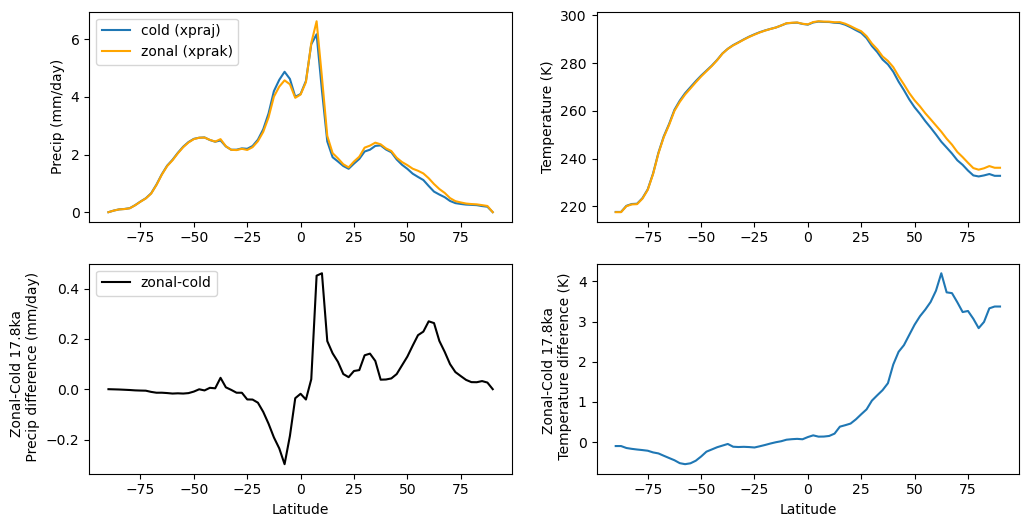

In [87]:
#Precip zonal averages


fig,(ax) = plt.subplots(nrows=2, ncols=2, figsize=(12,6))

ax[0,0].plot(ds_p['xpraj'].latitude,ds_p['xpraj']['precip_mm_srf'].mean(dim='longitude').mean(dim='t').isel(surface=0)*86400,label='cold (xpraj)'
)
ax[0,0].plot(ds_p['xprak'].latitude,ds_p['xprak']['precip_mm_srf'].mean(dim='longitude').mean(dim='t').isel(surface=0)*86400, color='orange',label='zonal (xprak)')


ax[1,0].plot(ds_p['xpraj'].latitude,ds_p['xprak']['precip_mm_srf'].mean(dim='longitude').mean(dim='t').isel(surface=0)*86400-ds_p['xpraj']['precip_mm_srf'].mean(dim='longitude').mean(dim='t').isel(surface=0)*86400,
color='black',label='zonal-cold')


ax[0,1].plot(ds_p['xpraj'].latitude,ds_tsurf['xpraj']['temp_mm_srf'].mean(dim='longitude').mean(dim='t').isel(surface=0)
)
ax[0,1].plot(ds_p['xprak'].latitude,ds_tsurf['xprak']['temp_mm_srf'].mean(dim='longitude').mean(dim='t').isel(surface=0), color='orange')

ax[1,1].plot(ds_p['xpraj'].latitude,ds_tsurf['xprak']['temp_mm_srf'].mean(dim='longitude').mean(dim='t').isel(surface=0)-ds_tsurf['xpraj']['temp_mm_srf'].mean(dim='longitude').mean(dim='t').isel(surface=0)
)
ax[1,0].set_xlabel('Latitude')
ax[1,1].set_xlabel('Latitude')

ax[0,0].set_ylabel('Precip (mm/day)')
ax[1,0].set_ylabel('Zonal-Cold 17.8ka  \n Precip difference (mm/day)')
ax[0,1].set_ylabel('Temperature (K)')
ax[1,1].set_ylabel('Zonal-Cold 17.8ka \n Temperature difference (K)')

ax[0,0].legend(loc='upper left')
ax[1,0].legend(loc='upper left')

             


In [72]:
ds_p['xpraj']['precip_mm_srf']


<xarray.DataArray 'precip_mm_srf' (t: 4249, surface: 1, latitude: 73,
                                   longitude: 96)>
array([[[[0., ..., 0.],
         ...,
         [0., ..., 0.]]],


       ...,


       [[[0., ..., 0.],
         ...,
         [0., ..., 0.]]]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * longitude  (longitude) float32 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * surface    (surface) float32 0.0
  * t          (t) object 5680-12-16 00:00:00 ... 6034-12-16 00:00:00
Attributes: (12/15)
    source:         Unified Model Output (Vn 4.6):
    name:           precip_mm_srf
    title:          TOTAL PRECIPITATION RATE     KG/M2/S
    date:           01/12/80
    time:           00:00
    long_name:      TOTAL PRECIPITATION RATE     KG/M2/S
    ...             ...
    stash_code:     5216
    submodel:       1
    processing:     monthly_mean_at_surface
    units:          kg m-2
    valid_min:      0.0
    valid_max:      0.00029141948

In [ ]:
### SST and SAT anomalies: do they correlate?

In [ ]:
### Wind Speed

In [6]:
ds_u850['xpraj']

<xarray.Dataset>
Dimensions:    (latitude: 72, longitude: 96, p: 1, t: 4249)
Coordinates:
  * latitude   (latitude) float32 88.75 86.25 83.75 ... -83.75 -86.25 -88.75
  * longitude  (longitude) float32 1.875 5.625 9.375 13.12 ... 350.6 354.4 358.1
  * p          (p) float32 850.0
  * t          (t) object 5680-12-16 00:00:00 ... 6034-12-16 00:00:00
Data variables:
    v_mm_p     (t, p, latitude, longitude) float32 ...
Attributes:
    history:                   Wed Jan 10 09:01:17 2024: ncrcat -O --no_tmp_f...
    NCO:                       "4.6.1"
    nco_openmp_thread_number:  1

In [154]:
u_850 = {}
v_850 = {}
wind_speed = {}
wind_speed_sorted = {}

for exp in ('xpraj','xprak','xpral'):
    # Extract U and V components at 850 hPa
    
    u_850[exp] = ds_u850[exp].u_mm_p.mean(dim='t').isel(p=0)  # Adjust variable name as needed
    v_850[exp] = ds_v850[exp].v_mm_p.mean(dim='t').isel(p=0)  # Adjust variable name as needed
    
    # Compute wind speed
    wind_speed[exp] = np.sqrt(u_850[exp]**2 + v_850[exp]**2)

    # Get coordinates
    lon = wind_speed[exp].longitude
    lat = wind_speed[exp].latitude
    # Convert 0-360° to -180° to 180°
    lon_180 = np.where(lon > 180, lon - 360, lon)

    # Sort the dataset to keep longitude order correct
    sorted_indices = np.argsort(lon_180)
    lon_sorted = lon_180[sorted_indices]
    wind_speed_sorted[exp] = wind_speed[exp].isel(longitude=sorted_indices)


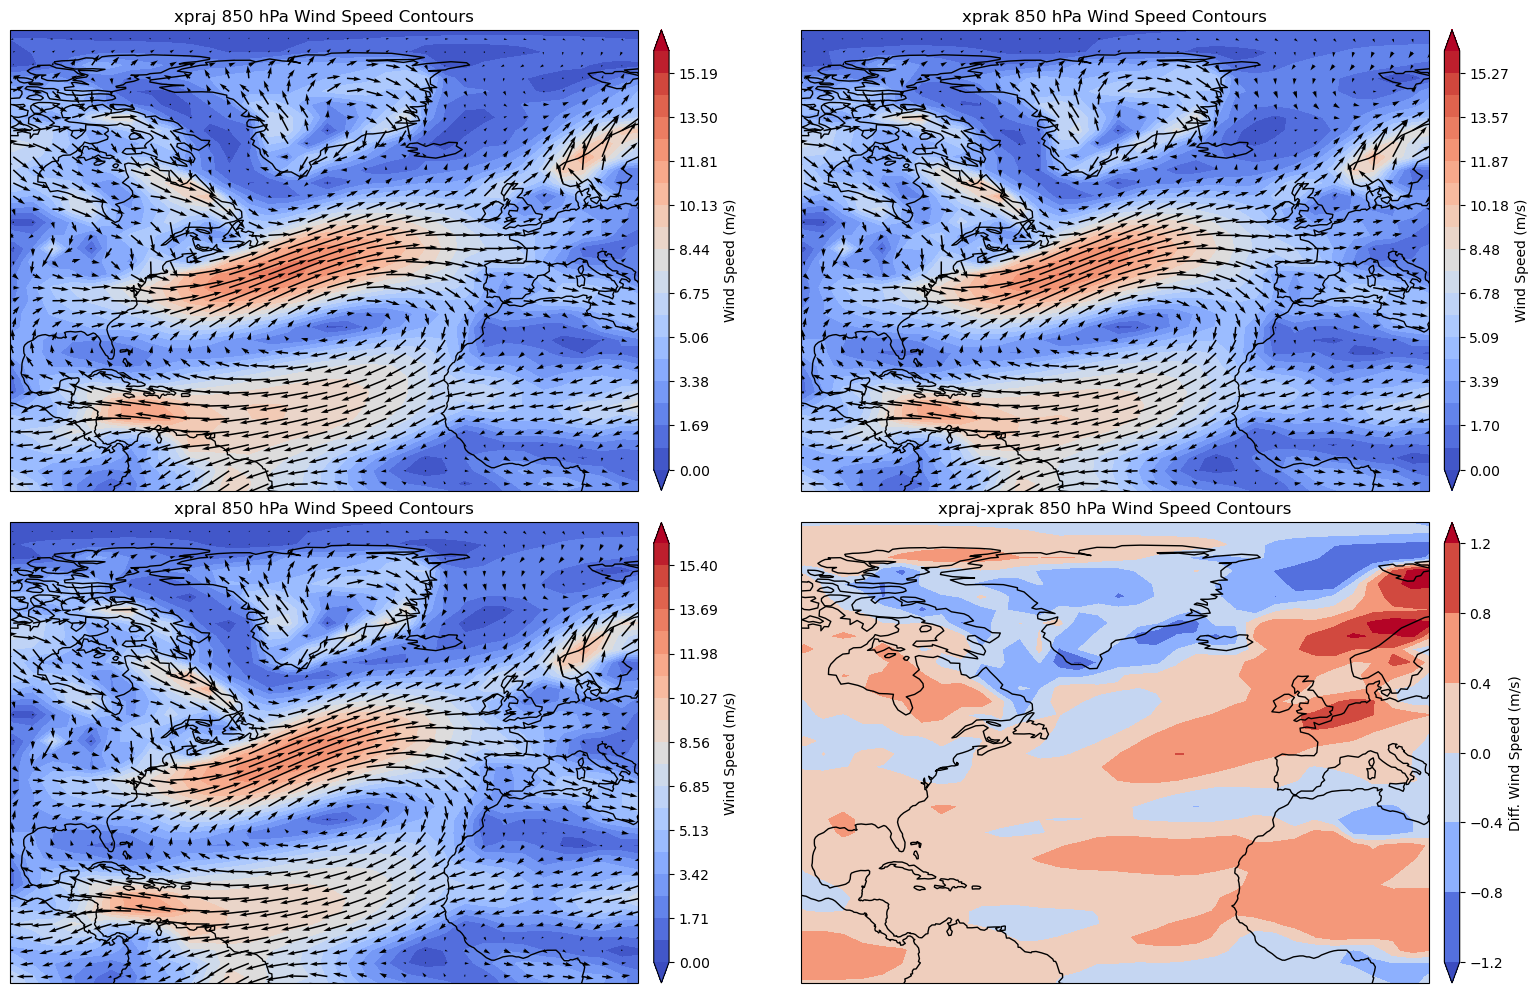

In [160]:

exp='xpraj'
# Get coordinates
lon = wind_speed[exp].longitude  # Adjust based on dataset
lat = wind_speed[exp].latitude

# Plot contours
fig, ax = plt.subplots(nrows=2, ncols=2,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(16,10))
ax=ax.flatten()

for i in range(4):
    ax[i].set_extent([-100,20, 0, 88], crs=ccrs.PlateCarree())

    # Add map features
    ax[i].add_feature(cfeature.COASTLINE)
    ax[i].add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

for i,exp in enumerate(['xpraj','xprak','xpral']):
    # Plot filled wind speed contours
    levels = np.linspace(0, wind_speed_sorted[exp].max(), 20)  # Adjust levels as needed
    contourf = ax[i].contourf(lon_sorted, lat, wind_speed_sorted[exp], levels=levels, cmap="coolwarm", extend="both")

    # Add contour lines
    #contour = ax.contour(lon, lat, wind_speed, levels=levels, colors='blue', linewidths=0.5)
    #ax.clabel(contour, inline=True, fontsize=8)

    # Add wind vectors (quiver plot)
    skip = 1  # Adjust for better readability
    ax[i].quiver(lon[::skip], lat[::skip], u_850[exp][::skip, ::skip], v_850[exp][::skip, ::skip], scale=200, color="black")

    # Add colorbar
    cbar = plt.colorbar(contourf, ax=ax[i], orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label("Wind Speed (m/s)")

    ax[i].set_title(f"{exp} 850 hPa Wind Speed Contours")

i=3
contourd = ax[i].contourf(lon_sorted, lat, wind_speed_sorted['xpraj']-wind_speed_sorted['xprak'], cmap="coolwarm", extend="both")
# Add colorbar
cbar = plt.colorbar(contourd, ax=ax[i], orientation="vertical", pad=0.02, aspect=30)
cbar.set_label("Diff. Wind Speed (m/s)")
ax[i].set_title(f"xpraj-xprak 850 hPa Wind Speed Contours")


plt.tight_layout()
plt.savefig("my_output/mean_windspeed.png")


In [151]:
# SLP data
ds_slp = {}

with mf.Timer('SLP'):
    for exp in ("xpraj","xprak","xpral"):
        ds_slp[exp] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.msl.daily.nc')




[SLP]
Elapsed: 131.6925446987152


<Figure size 640x480 with 0 Axes>

In [47]:
ds_slp[exp]

<xarray.Dataset>
Dimensions:    (t: 31350, longitude: 96, latitude: 73, msl: 1)
Coordinates:
  * t          (t) object 6380-12-01 12:00:00 ... 6467-12-30 12:00:00
  * longitude  (longitude) float32 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * latitude   (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * msl        (msl) float32 0.0
Data variables:
    p_dm_msl   (t, msl, latitude, longitude) float32 ...
Attributes:
    CDI:          Climate Data Interface version 1.9.3 (http://mpimet.mpg.de/...
    Conventions:  CF-1.6
    history:      Mon Nov 27 15:03:37 2023: cdo mergetime temp/slp_6380.nc te...
    CDO:          Climate Data Operators version 1.9.3 (http://mpimet.mpg.de/...

In [45]:
import scipy.signal as signal

In [97]:
ds_slp[exp].p_dm_msl

<xarray.DataArray 'p_dm_msl' (t: 31350, msl: 1, latitude: 73, longitude: 96)>
array([[[[104770.66 , ..., 104770.66 ],
         ...,
         [103734.164, ..., 103734.164]]],


       ...,


       [[[104082.945, ..., 104082.945],
         ...,
         [102964.07 , ..., 102964.07 ]]]], dtype=float32)
Coordinates:
  * t          (t) object 6380-12-01 12:00:00 ... 6467-12-30 12:00:00
  * longitude  (longitude) float32 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * latitude   (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * msl        (msl) float32 0.0
Attributes: (12/13)
    standard_name:  air_pressure_at_sea_level
    long_name:      PRESSURE AT MEAN SEA LEVEL
    units:          Pa
    source:         Unified Model Output (Vn 4.6):
    name:           p_dm_msl
    title:          PRESSURE AT MEAN SEA LEVEL
    ...             ...
    time:           00:00
    pp_name:        Pressure
    pcmdi_name:     psl
    stash_code:     16222
    submodel:       1
    processing:     daily_mean_at_mean_sea_level

In [120]:
# Compute anomalies by removing the time mean at each grid point

# Define Butterworth band-pass filter (2-6 days)
dt = 1  # Time step in days (daily data)
fs = 1 / dt  # Sampling frequency (1/day)
nyquist = 0.5 * fs  # Nyquist frequency = 0.5 cycles/day

lowcut, highcut = 1/6, 1/2  # Periods: 6 days (low) to 2 days (high)
low, high = lowcut / nyquist, min(highcut / nyquist, 0.99)  # Normalize and fix highcut

order = 3  # Filter order

def butter_bandpass_filter(data, low, high, order):
    """Apply a Butterworth band-pass filter along the time axis."""
    if np.all(np.isnan(data)):  # Avoid filtering NaN-only data
        return data
    b, a = signal.butter(order, [low, high], btype="band")
    return signal.filtfilt(b, a, np.asarray(data), axis=0)  # Ensure NumPy array




slp_clim = {}
slp_anom = {}
slp_filtered = {}
storm_track = {}
storm_track_sorted = {}




for exp in ("xpraj","xprak","xpral"):
    slp_clim[exp] = ds_slp[exp].mean(dim="t")/100 #Convert to hPa
    slp_anom[exp] = ds_slp[exp].p_dm_msl/100 - slp_clim[exp]
    
    # Apply the band-pass filter using vectorized ufunc
    slp_filtered[exp] = xr.apply_ufunc(
        butter_bandpass_filter, slp_anom[exp],
        input_core_dims=[["t"]],  # Filtering along "time" dimension
        output_core_dims=[["t"]],  # Keep the time dimension
        kwargs={"low": low, "high": high, "order": order},
        vectorize=True,  # Apply independently to each lat-lon point
        dask="parallelized",  # Enable parallel computation if using dask
        keep_attrs=True
    )
    # Compute variance of the filtered anomalies (storm track intensity)
    storm_track[exp] = slp_filtered[exp].var(dim="t")

    # Get coordinates
    lon = storm_track[exp].longitude
    lat = storm_track[exp].latitude
    # Convert 0-360° to -180° to 180°
    lon_180 = np.where(lon > 180, lon - 360, lon)

    # Sort the dataset to keep longitude order correct
    sorted_indices = np.argsort(lon_180)
    lon_sorted = lon_180[sorted_indices]
    storm_track_sorted[exp] = storm_track[exp].isel(longitude=sorted_indices)







Text(0.5, 1.0, 'xpraj-xprak Stormtrack intensity')

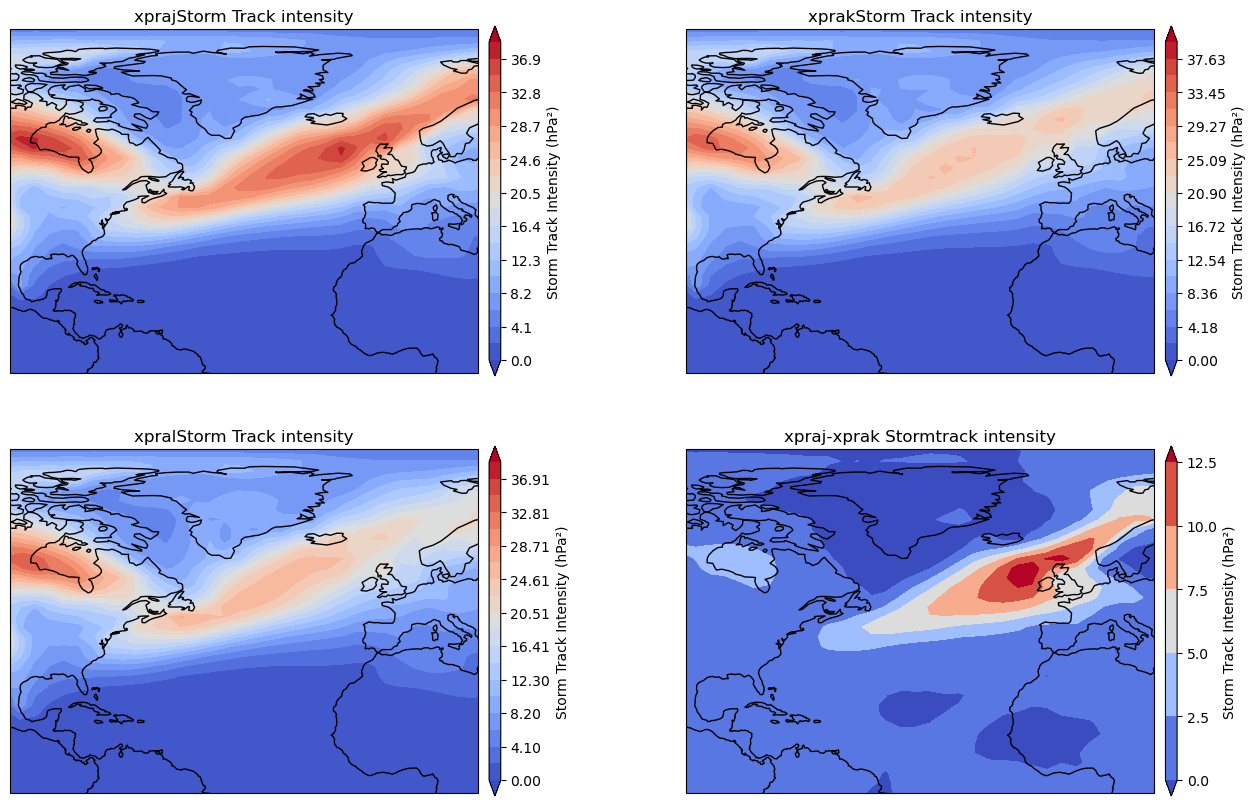

In [121]:


# Plot contours
fig, ax = plt.subplots(nrows=2, ncols=2,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(16,10))
ax=ax.flatten()

for i in range(4):
    ax[i].set_extent([-100,20, 0, 88], crs=ccrs.PlateCarree())

    # Add map features
    ax[i].add_feature(cfeature.COASTLINE)
    ax[i].add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

for i,exp in enumerate(['xpraj','xprak','xpral']):
     # Plot filled contours
     levels = np.linspace(0, storm_track[exp].p_dm_msl.max(), 20)
     contourf = ax[i].contourf(lon_sorted, lat, storm_track_sorted[exp].p_dm_msl.isel(msl=0), levels=levels, cmap="coolwarm", extend="both",
                              transform=ccrs.PlateCarree())

     # Add colorbar
     cbar = plt.colorbar(contourf, ax=ax[i], orientation="vertical", pad=0.02, aspect=30)
     cbar.set_label("Storm Track Intensity (hPa²)")



     ax[i].set_title(f"{exp}Storm Track intensity")

i=3
contourd = ax[i].contourf(lon_sorted, lat, storm_track_sorted['xpraj'].p_dm_msl.isel(msl=0)-storm_track['xprak'].p_dm_msl.isel(msl=0), cmap="coolwarm", extend="both",
                         transform=ccrs.PlateCarree())
# Add colorbar
cbar = plt.colorbar(contourd, ax=ax[i], orientation="vertical", pad=0.02, aspect=30)
cbar.set_label("Storm Track Intensity (hPa²)")
ax[i].set_title(f"xpraj-xprak Stormtrack intensity")



#I believe there is still a mistake, it should be a magnitude lower?



In [103]:

# Get coordinates
lon = storm_track.longitude
lat = storm_track.latitude

# Plot storm track variance
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

# Plot filled contours
levels = np.linspace(0, storm_track.p_dm_msl.max(), 20)
contourf = ax.contourf(lon, lat, storm_track.p_dm_msl.isel(msl=0), levels=levels, cmap="coolwarm", extend="both")

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax, orientation="vertical", pad=0.02, aspect=30)
cbar.set_label("Storm Track Intensity (hPa²)")





AttributeError: 'dict' object has no attribute 'longitude'

In [105]:
storm_track[exp].latitude

<xarray.DataArray 'latitude' (latitude: 73)>
array([ 90. ,  87.5,  85. ,  82.5,  80. ,  77.5,  75. ,  72.5,  70. ,  67.5,
        65. ,  62.5,  60. ,  57.5,  55. ,  52.5,  50. ,  47.5,  45. ,  42.5,
        40. ,  37.5,  35. ,  32.5,  30. ,  27.5,  25. ,  22.5,  20. ,  17.5,
        15. ,  12.5,  10. ,   7.5,   5. ,   2.5,   0. ,  -2.5,  -5. ,  -7.5,
       -10. , -12.5, -15. , -17.5, -20. , -22.5, -25. , -27.5, -30. , -32.5,
       -35. , -37.5, -40. , -42.5, -45. , -47.5, -50. , -52.5, -55. , -57.5,
       -60. , -62.5, -65. , -67.5, -70. , -72.5, -75. , -77.5, -80. , -82.5,
       -85. , -87.5, -90. ], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [87]:
ds_sicec_spans_sm = {}
ds_sicec_spans_ssd = {}

ds_siced_spans_sm = {}
ds_siced_spans_ssd = {}

ds_mld_spans_sm = {}
ds_mld_spans_ssd = {}

for expt in ('xpraj','xprak','xpral'):
    #Monthly averages (I am interested in Sept and March extent) 
    # Model has 360 days, every month is 30 days - no weighting is needed
    ds_sicec_spans_sm[expt] = {}
    ds_sicec_spans_ssd[expt] = {}

    ds_siced_spans_sm[expt] = {}
    ds_siced_spans_ssd[expt] = {}

    ds_mld_spans_sm[expt] = {}
    ds_mld_spans_ssd[expt] = {}
    #try:
    ds_sicec_spans_sm[expt] = ds_sicec[expt].groupby("t.month").mean("t")
    ds_sicec_spans_ssd[expt] = ds_sicec[expt].groupby("t.month").std("t")
    ds_siced_spans_sm[expt] = ds_siced[expt].groupby("t.month").mean("t")
    ds_siced_spans_ssd[expt] = ds_siced[expt].groupby("t.month").std("t")
    
    #except:
     #       print(f"skip for {expt}")

/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dty

In [89]:
ds_sicec_spans_sm['xpraj']

<xarray.Dataset>
Dimensions:         (month: 12, surface: 1, latitude: 73, longitude: 96)
Coordinates:
  * latitude        (latitude) float32 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * longitude       (longitude) float32 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * surface         (surface) float32 0.0
  * month           (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    iceconc_mm_srf  (month, surface, latitude, longitude) float32 1.0 ... nan
Attributes:
    history:                   Wed Jan 10 08:56:44 2024: ncrcat -O --no_tmp_f...
    NCO:                       "4.6.1"
    nco_openmp_thread_number:  1

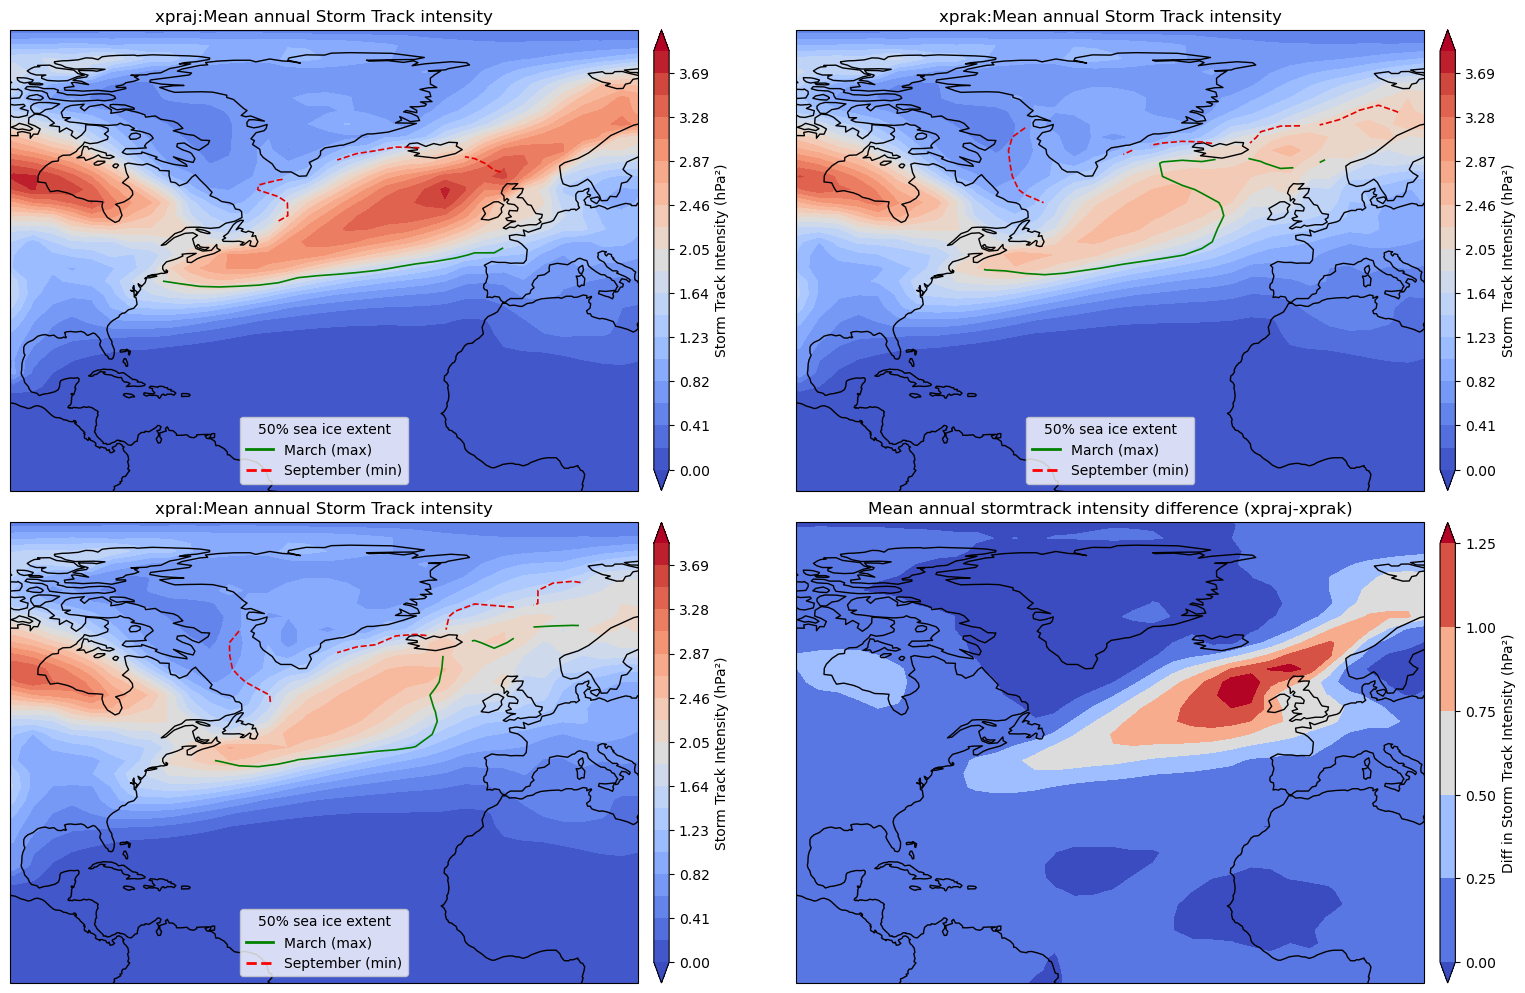

In [159]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Define custom legend elements with different line styles
march_line = Line2D([0], [0], color='green', linestyle='-', linewidth=2, label='March (max)')
sept_line = Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='September (min)')



s = 1/10 #scaling factor, something is off by a magnitude! CHECK LATER WHAT
### Include also sea ice (min and max.)
exp = 'xpraj'
# Get coordinates
lon = storm_track[exp].longitude
lat = storm_track[exp].latitude
lon_b, lat_b = tb.create_coordinate_edges(lon), lat
levels = np.linspace(0, storm_track[exp].p_dm_msl.max()/10, 20)

# Plot contours
fig, ax = plt.subplots(nrows=2, ncols=2,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(16,10))
ax=ax.flatten()

for i in range(4):
    ax[i].set_extent([-100,20, 0, 88], crs=ccrs.PlateCarree())

    # Add map features
    ax[i].add_feature(cfeature.COASTLINE)
    ax[i].add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

for i,exp in enumerate(['xpraj','xprak','xpral']):
     # Plot filled contours
     
     contourf = ax[i].contourf(lon_sorted, lat, storm_track_sorted[exp].p_dm_msl.isel(msl=0)*s, levels=levels, cmap="coolwarm", extend="both",
                              transform=ccrs.PlateCarree())


    # Plot Seaice 50% boundaries
     ax[i].contour(lon, lat,ds_sicec_spans_sm[exp]['iceconc_mm_srf'].sel(month=3).isel(surface=0), transform=ccrs.PlateCarree(), 
                                #norm=normSST, cmap=cmc.navia, 
                                       levels=[0.5], colors='green',
                      linewidths=1.2, linestyles='-',alpha=1)
     ax[i].contour(lon, lat,ds_sicec_spans_sm[exp]['iceconc_mm_srf'].sel(month=9).isel(surface=0), transform=ccrs.PlateCarree(), 
                                #norm=normSST, cmap=cmc.navia, 
                                       levels=[0.5], colors='xkcd:red',
                      linewidths=1.2, linestyles='--',alpha=1)

     # Add colorbar
     cbar = plt.colorbar(contourf, ax=ax[i], orientation="vertical", pad=0.02, aspect=30)
     cbar.set_label("Storm Track Intensity (hPa²)")


     ax[i].legend(handles=[march_line,sept_line],loc="lower center",title='50% sea ice extent')
     ax[i].set_title(f"{exp}:Mean annual Storm Track intensity")

i=3
contourd = ax[i].contourf(lon_sorted, lat, (storm_track_sorted['xpraj'].p_dm_msl.isel(msl=0)-storm_track['xprak'].p_dm_msl.isel(msl=0))*s, cmap="coolwarm", extend="both",
                         transform=ccrs.PlateCarree())
# Add colorbar
cbar = plt.colorbar(contourd, ax=ax[i], orientation="vertical", pad=0.02, aspect=30)
cbar.set_label("Diff in Storm Track Intensity (hPa²)")
ax[i].set_title(f"Mean annual stormtrack intensity difference (xpraj-xprak)")



#I believe there is still a mistake, it should be a magnitude lower! I do convert it here, but i need to follow up this later!

plt.tight_layout()
plt.savefig("my_output/mean_stormtrack_intensity.png")


In [132]:
#Now make also a seasonal (DJFM) winter storm track plot.

In [139]:
# Compute anomalies by removing the time mean at each grid point

# Define Butterworth band-pass filter (2-6 days)
dt = 1  # Time step in days (daily data)
fs = 1 / dt  # Sampling frequency (1/day)
nyquist = 0.5 * fs  # Nyquist frequency = 0.5 cycles/day

lowcut, highcut = 1/6, 1/2  # Periods: 6 days (low) to 2 days (high)
low, high = lowcut / nyquist, min(highcut / nyquist, 0.99)  # Normalize and fix highcut

order = 3  # Filter order

def butter_bandpass_filter(data, low, high, order):
    """Apply a Butterworth band-pass filter along the time axis."""
    if np.all(np.isnan(data)):  # Avoid filtering NaN-only data
        return data
    b, a = signal.butter(order, [low, high], btype="band")
    return signal.filtfilt(b, a, np.asarray(data), axis=0)  # Ensure NumPy array




slp_clim_DJFM = {}
slp_anom_DJFM = {}
slp_filtered_DJFM = {}
storm_track_DJFM = {}
storm_track_sorted_DJFM = {}




for exp in ("xpraj","xprak","xpral"):
    slp_clim_DJFM[exp] = ds_slp[exp].sel(t=ds_slp[exp].t.dt.month.isin([12, 1, 2, 3])).mean(dim='t')/100 #Convert to hPa
    slp_anom_DJFM[exp] = ds_slp[exp].sel(t=ds_slp[exp].t.dt.month.isin([12, 1, 2, 3]))/100 - slp_clim_DJFM[exp]
    
    # Apply the band-pass filter using vectorized ufunc
    slp_filtered_DJFM[exp] = xr.apply_ufunc(
        butter_bandpass_filter, slp_anom_DJFM[exp],
        input_core_dims=[["t"]],  # Filtering along "time" dimension
        output_core_dims=[["t"]],  # Keep the time dimension
        kwargs={"low": low, "high": high, "order": order},
        vectorize=True,  # Apply independently to each lat-lon point
        dask="parallelized",  # Enable parallel computation if using dask
        keep_attrs=True
    )
    # Compute variance of the filtered anomalies (storm track intensity)
    storm_track_DJFM[exp] = slp_filtered_DJFM[exp].var(dim="t")

    # Get coordinates
    lon = storm_track_DJFM[exp].longitude
    lat = storm_track_DJFM[exp].latitude
    # Convert 0-360° to -180° to 180°
    lon_180 = np.where(lon > 180, lon - 360, lon)

    # Sort the dataset to keep longitude order correct
    sorted_indices_DJFM = np.argsort(lon_180)
    lon_sorted = lon_180[sorted_indices_DJFM]
    storm_track_sorted_DJFM[exp] = storm_track_DJFM[exp].isel(longitude=sorted_indices_DJFM)







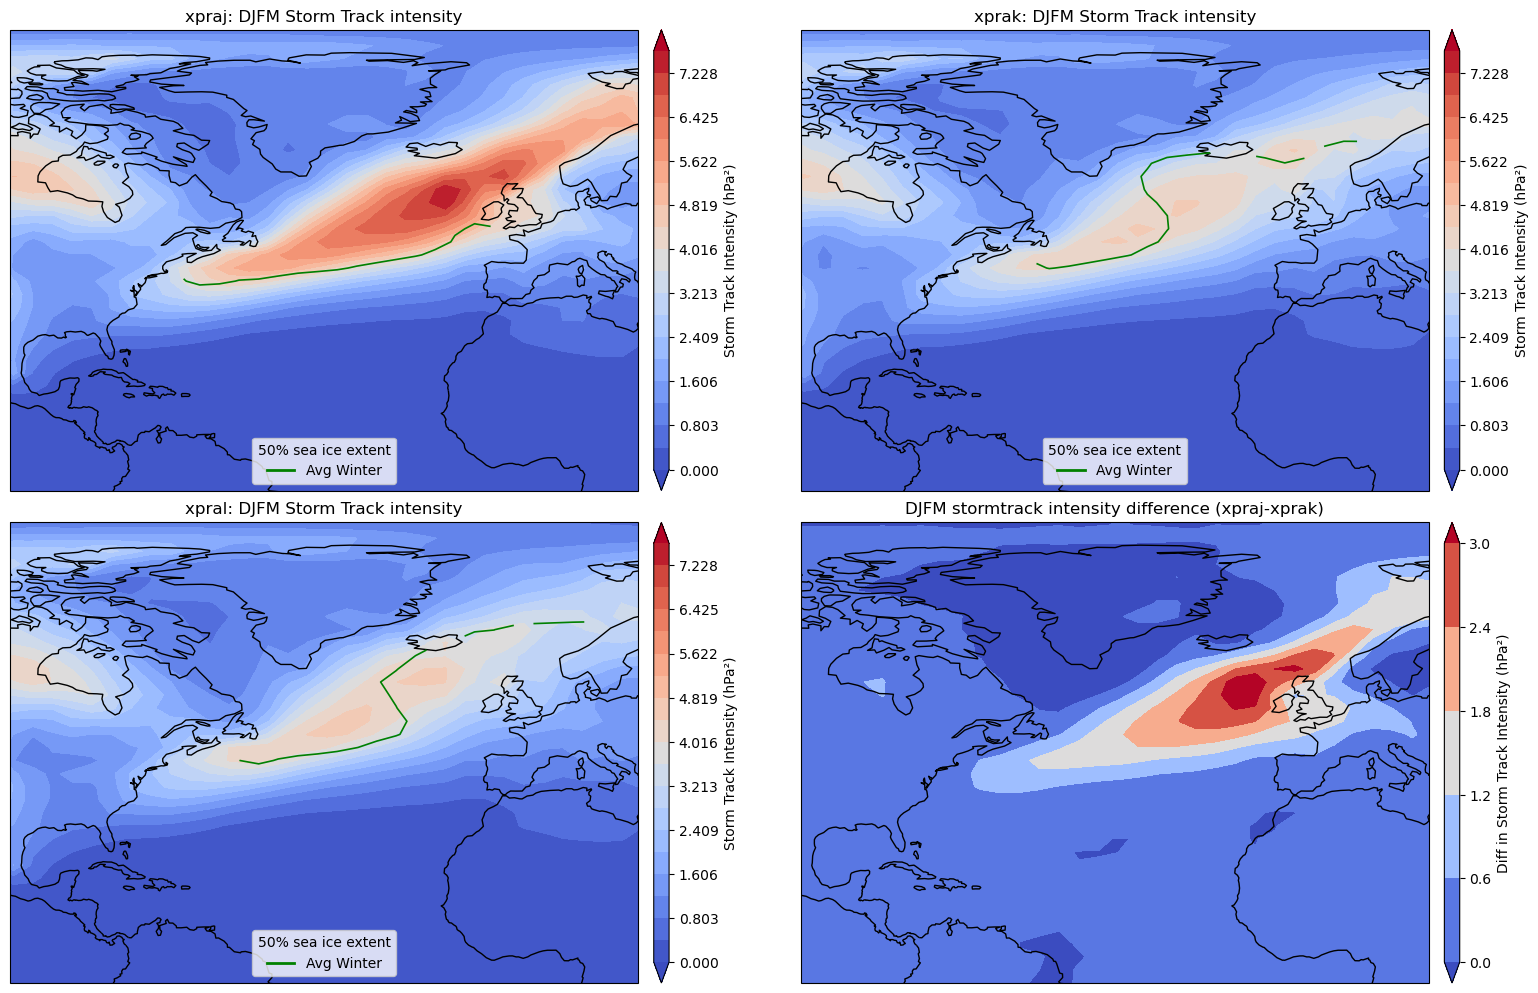

In [158]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Define custom legend elements with different line styles
march_line = Line2D([0], [0], color='green', linestyle='-', linewidth=2, label='Avg Winter')
#sept_line = Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='September (min)')



s = 1/10 #scaling factor, something is off by a magnitude! CHECK LATER WHAT
### Include also sea ice (min and max.)
exp = 'xpraj'
# Get coordinates
lon = storm_track_DJFM[exp].longitude
lat = storm_track_DJFM[exp].latitude
lon_b, lat_b = tb.create_coordinate_edges(lon), lat
levels = np.linspace(0, storm_track_DJFM[exp].p_dm_msl.max()/10, 20)

# Plot contours
fig, ax = plt.subplots(nrows=2, ncols=2,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(16,10))
ax=ax.flatten()

for i in range(4):
    ax[i].set_extent([-100,20, 0, 88], crs=ccrs.PlateCarree())

    # Add map features
    ax[i].add_feature(cfeature.COASTLINE)
    ax[i].add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

for i,exp in enumerate(['xpraj','xprak','xpral']):
     # Plot filled contours
     
     contourf = ax[i].contourf(lon_sorted, lat, storm_track_sorted_DJFM[exp].p_dm_msl.isel(msl=0)*s, levels=levels, cmap="coolwarm", extend="both",
                              transform=ccrs.PlateCarree())


    # Plot Seaice 50% boundaries
     ax[i].contour(lon, lat,ds_sicec_spans_sm[exp]['iceconc_mm_srf'].sel(month=ds_sicec_spans_sm[exp]['iceconc_mm_srf'].month.isin([12, 1, 2, 3])).isel(surface=0).mean(dim='month'), transform=ccrs.PlateCarree(), 
                                #norm=normSST, cmap=cmc.navia, 
                                       levels=[0.5], colors='green',
                      linewidths=1.2, linestyles='-',alpha=1)
     
     # Add colorbar
     cbar = plt.colorbar(contourf, ax=ax[i], orientation="vertical", pad=0.02, aspect=30)
     cbar.set_label("Storm Track Intensity (hPa²)")


     ax[i].legend(handles=[march_line],loc="lower center",title='50% sea ice extent')
     ax[i].set_title(f"{exp}: DJFM Storm Track intensity")

i=3
contourd = ax[i].contourf(lon_sorted, lat, (storm_track_sorted_DJFM['xpraj'].p_dm_msl.isel(msl=0)-storm_track_DJFM['xprak'].p_dm_msl.isel(msl=0))*s, cmap="coolwarm", extend="both",
                         transform=ccrs.PlateCarree())
# Add colorbar
cbar = plt.colorbar(contourd, ax=ax[i], orientation="vertical", pad=0.02, aspect=30)
cbar.set_label("Diff in Storm Track Intensity (hPa²)")
ax[i].set_title(f"DJFM stormtrack intensity difference (xpraj-xprak)")



#I believe there is still a mistake, it should be a magnitude lower! I do convert it here, but i need to follow up this later!

plt.tight_layout()
plt.savefig("my_output/DJFM_stormtrack_intensity.png")


In [200]:
ds_snowcover['xpraj']

<xarray.Dataset>
Dimensions:           (latitude: 73, longitude: 96, t: 4249, surface: 1)
Coordinates:
  * latitude          (latitude) float32 90.0 87.5 85.0 ... -85.0 -87.5 -90.0
  * longitude         (longitude) float32 0.0 3.75 7.5 ... 348.8 352.5 356.2
  * surface           (surface) float32 0.0
  * t                 (t) object 5680-12-16 00:00:00 ... 6034-12-16 00:00:00
Data variables:
    snowdepth_mm_srf  (t, surface, latitude, longitude) float32 0.0 ... 5e+04
Attributes:
    history:                   Wed Jan 10 09:05:07 2024: ncrcat -O --no_tmp_f...
    NCO:                       "4.6.1"
    nco_openmp_thread_number:  1

In [188]:

snowcover_climatology = {}
soiltemp_climatology = {}



for exp in ('xpraj','xprak','xpral'):
    # Group by calendar month and compute the mean
    snowcover_climatology[exp] = ds_snowcover[exp].groupby("t.month").mean(dim="t")
    soiltemp_climatology[exp] = ds_soiltemp[exp].groupby("t.month").mean(dim="t")

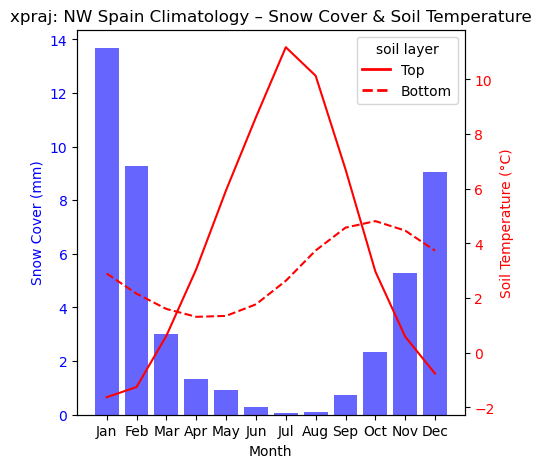

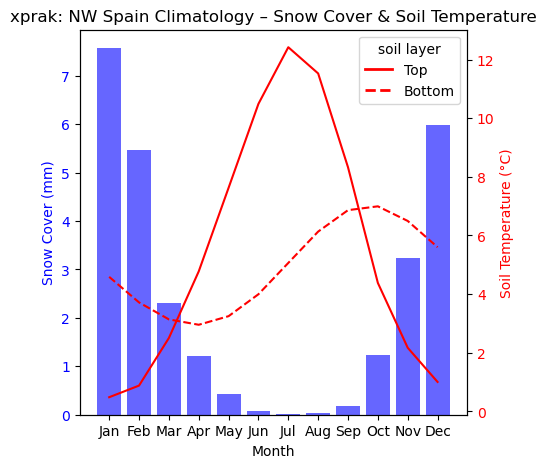

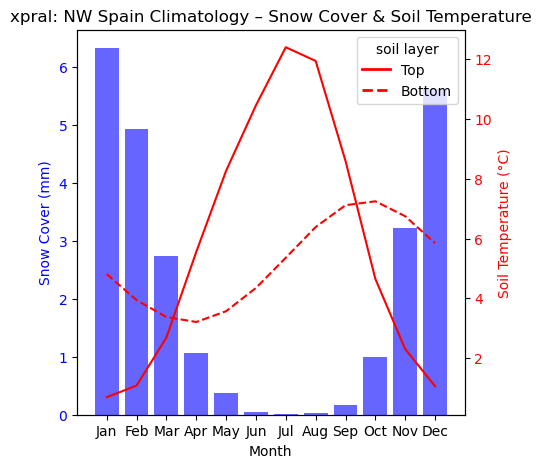

In [217]:


for exp in ('xpraj','xprak','xpral'):

    ## Climatology for NW Spain
    
    snow = snowcover_climatology[exp].sel(longitude=slice(350,360),latitude=slice(45,40)).mean(dim='latitude').mean(dim='longitude').isel(surface=0).snowdepth_mm_srf
    soil1 = soiltemp_climatology[exp].sel(longitude=slice(350,360),latitude=slice(45,40)).mean(dim='latitude').mean(dim='longitude').isel(level6=0).soiltemp_mm_soil
    soil2 = soiltemp_climatology[exp].sel(longitude=slice(350,360),latitude=slice(45,40)).mean(dim='latitude').mean(dim='longitude').isel(level6=1).soiltemp_mm_soil
    soil3 = soiltemp_climatology[exp].sel(longitude=slice(350,360),latitude=slice(45,40)).mean(dim='latitude').mean(dim='longitude').isel(level6=2).soiltemp_mm_soil
    soil4 = soiltemp_climatology[exp].sel(longitude=slice(350,360),latitude=slice(45,40)).mean(dim='latitude').mean(dim='longitude').isel(level6=3).soiltemp_mm_soil

    # Extract climatology for Santander (assuming lat/lon indexing)
    snow = snowcover_climatology[exp].sel(latitude=43.4623, longitude=360-3.8099, method="nearest").isel(surface=0).snowdepth_mm_srf


    
    # Get months for the x-axis
    months = range(1, 13)  # January (1) to December (12)
    
    # Create figure and axis
    fig, ax1 = plt.subplots(figsize=(5, 5))
    
    # Plot Snow Cover (Left Y-Axis)
    ax1.bar(months, snow, color="blue", alpha=0.6, label="Snow Cover")
    #ax1.plot(months, snow, color="grey", label="Snow Cover",linestyle="-")
    ax1.set_ylabel("Snow Cover (mm)", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    
    # Create a second y-axis
    ax2 = ax1.twinx()
    
    # Plot Soil Temperature (Right Y-Axis)
    
    ax2.plot(months, soil1-273.15, color="red", label="Soil Temperature",linestyle="-")
    ax2.plot(months, soil4-273.15, color="red", label="Soil Temperature",linestyle="--")
    ax2.set_ylabel("Soil Temperature (°C)", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    
    
    # Define custom legend elements with different line styles
    top_line = Line2D([0], [0], color='red', linestyle='-', linewidth=2, label='Top')
    bottom_line = Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Bottom')
    #sept_line = Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='September (min)')
    ax1.legend(handles=[top_line,bottom_line],loc="upper right", title='soil layer')
    
    # X-axis labels and title
    ax1.set_xticks(months)
    ax1.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    ax1.set_xlabel("Month")
    plt.title(f"{exp}: NW Spain Climatology – Snow Cover & Soil Temperature")

    #plt.savefig(f"my_output/snowsoil_{exp}.png")
    
    


